---
skip_execution: true
---


# 2. 1D Poisson problem with TV denoising using MYULA


We consider a Bayesian inverse problem in which we infer a conductivity field $\sigma$ from potential $u$ measurements everywhere in a 1D domain, similar problem in a 2D domain was presented in {ref}`PDE-based-BIP-using-CUQIpy-and-CUQIpy-FEniCS-plugin`. The forward map from the conductivity $\sigma$ to the measurements is governed by the 1D Poisson equation with zero Neumann boundary conditions at the left and zero Dirichlet boundary conditions at the right, and source term $f(x)=10$. 
    
$$ \nabla \cdot \left( e^{m(x)} \nabla u(x) \right) = f(x) \;\; \text{ in } \;\;\Omega = (0,1) $$

where we use log parameterization $\sigma = e^{m(x)}$, to ensure positivity of the inferred conductivity. We denote this forward map as $\mathbf{F}(m)=y$, which for given $m$ returns the measurement $y$ of the potential $u$ everywhere in the domain.

In this section, we present two Bayesian inverse problem setups for this problem. Both setups share the same forward model and likelihood, and differ only in the choice of the prior for the log conductivity field $m$:
- In the first setup, we use a GMRF prior.
- In the second setup, we use a TV-type implicit prior.

We compare the results obtained from these two setups to see the effect of the choice of the prior on the posterior distribution and the inferred conductivity field.


## Table of Contents
- 2.1. Learning objectives
- 2.2. Set up CUQIpy PDE object and the forward model
- 2.3. BIP setup with GMRF prior
- 2.4. BIP setup with TV-type implicit prior



## 2.1. Learning objectives <a class="anchor" id="r-learning-objectives"></a>
- Describe the MYULA algorithm and how it is different from ULA.
- Describe how Moreau-Yosida regularization is used to overcome the non-differentiability of the TV prior in the MYULA algorithm.
- Write the MYULA step in terms of the proximal operator of the TV prior.
- Create `RestorationPrior` and `MoreauYoshidaPrior` objects in CUQIpy to create a TV-type implicit prior.
- Sample from the posterior distribution using the MYULA algorithm and analyze the results.



<div style="border: 2px solid #FFB74D; background-color: #FFF3E0; border-radius: 8px; padding: 10px; font-family: Arial, sans-serif; color: #333; box-shadow: 2px 2px 8px rgba(0, 0, 0, 0.1); max-width: 750px; margin: 0 auto;">
  <strong style="color: #E65100;">⚠️ Note:</strong> 

- This notebook is under the [GPLv3.0 license](LICENSE).

- This notebook was run on a machine locally and not using github actions for this book. To run this notebook on your machine, you need to have [CUQIpy-FEniCS installed](https://github.com/CUQI-DTU/CUQIpy-FEniCS).

</div>

We import the necessary libraries and modules.

In [ ]:
from cuqi.distribution import Gaussian, GMRF, JointDistribution
from cuqi.implicitprior import RestorationPrior, MoreauYoshidaPrior
from cuqi.sampler import  ULA
from cuqi.model import PDEModel
from cuqi.array import CUQIarray
from cuqi.geometry import Continuous1D
from cuqipy_fenics.geometry import FEniCSContinuous
from cuqipy_fenics.pde import SteadyStateLinearFEniCSPDE
import numpy as np
import dolfin as dl
import matplotlib.pyplot as plt
from skimage.restoration import denoise_tv_chambolle
import ufl

# Set logging level of dl
dl.set_log_level(dl.LogLevel.ERROR)

## 2.2. Set up CUQIpy PDE object and the forward model

In this section, we set up the CUQIpy PDE object for the 1D Poisson problem and define the forward model. First we create the mesh and the function space for the PDE problem using `dolfin` library from [FEniCS](https://fenicsproject.org/).

In [22]:
n = 80 # number of nodes in the mesh
mesh = dl.IntervalMesh(n-1, 0, 1)

# Function space for the solution u
solution_function_space = dl.FunctionSpace(mesh, 'Lagrange', 1)
# Function space for the parameter m
parameter_function_space = dl.FunctionSpace(mesh, 'Lagrange', 1)

We then define the FEniCS variational form for the 1D poission problem.

In [23]:
source_signal =  10 # source term in the PDE
def form(m,u,p):
    return ufl.exp(m)*ufl.inner(ufl.grad(u), ufl.grad(p))*ufl.dx\
          - dl.Constant(source_signal)*p*ufl.dx

And define the Dirichlet boundary condition for the PDE problem.

In [24]:
def u_boundary(x, on_boundary):
    return on_boundary and  ((x[0] > 1-dl.DOLFIN_EPS) )

dirichlet_bc_expression = dl.Expression("right_bc*(x[0]>endpoint-eps)", eps=dl.DOLFIN_EPS, endpoint=1, left_bc=0, right_bc=1, degree=1)

After that we create CUQIpy-FEniCS PDE object, to which we supply the form, the function spaces, the boundary conditions, and the adjoint boundary conditions which are needed for the gradient-based sampling methods ULA and MYULA that we will use later in this notebook.



In [ ]:
dirichlet_bc = [dl.DirichletBC(solution_function_space, dirichlet_bc_expression, u_boundary)]
adjoint_dirichlet_bc = [dl.DirichletBC(
            solution_function_space, dl.Constant(0), u_boundary)]

PDE = SteadyStateLinearFEniCSPDE(
            form, mesh, solution_function_space, parameter_function_space, dirichlet_bc, adjoint_dirichlet_bc)


Then we create the CUQIpy forward model to which we supply the PDE object, and the domain and the range geometries.

In [ ]:
domain_geometry = FEniCSContinuous(parameter_function_space)
range_geometry = FEniCSContinuous(solution_function_space)
F = PDEModel(PDE,range_geometry,domain_geometry)

## 2.3. BIP setup with GMRF prior

We set up the following Bayesian model

$$
\begin{align*}
m &\sim \mathrm{GMRF}(0, 25)\\
y|m &\sim \mathrm{Gaussian}(\mathbf{F}(m), \mathrm{noise}^2\mathbf{I})\\
\end{align*}
$$

where $\mathrm{noise}^2$ is the variance of the Gaussian noise in the measurements.





#### GMRF prior

We create a GMRF prior for the log conductivity field $m$ as follows

In [ ]:
m = GMRF(np.zeros(domain_geometry.par_dim),25) 

#### The true signal
We choose a true log conductivity field  $m$ to be a piecewise constant function given as follows

[[<matplotlib.lines.Line2D at 0x12aee8100>]]

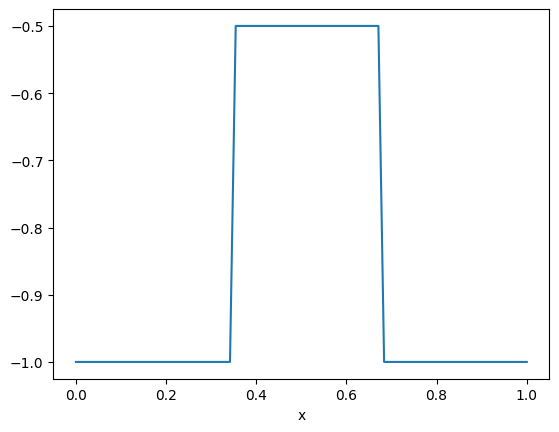

In [ ]:
m_true_array = np.ones(n)*-1
m_true_array[int(n/3):2*int(n/3)] = -0.5
m_true = CUQIarray(m_true_array, geometry=domain_geometry)
m_true.plot()

####  The likelihood, the data, and the posterior distribution
We then create the data distribution assuming a noise level **noise**

In [ ]:
noise = 0.02
y = Gaussian(
    mean=F(m), cov=noise**2*np.eye(range_geometry.par_dim), geometry=range_geometry)

And we generate the data $y^\text{obs}$ by sampling from the data distribution at the true log conductivity field.

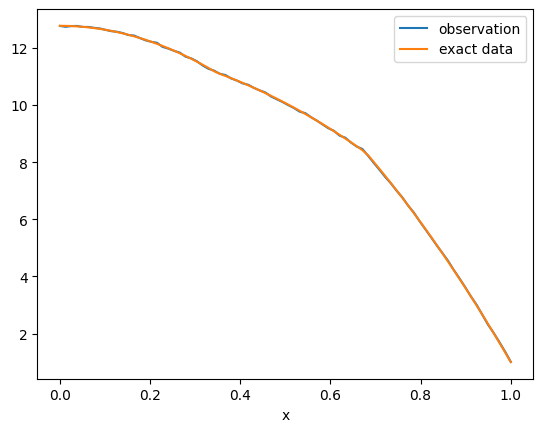

In [30]:
y_obs = y(m=m_true.parameters).sample()

y_obs.plot(label="observation")
F(m_true).plot(label="exact data")
plt.legend()


The posterior distribution is given by

$$
p(m|y^\text{obs}) \propto p(y^\text{obs}|m)p(m),
$$

where $p(y^\text{obs}|m)$ is the likelihood function, the data distribution PDF at fixed $y^\text{obs}$, and $p(m)$ is the prior distribution PDF. The posterior distribution can be equivalently written as

$$
p(m|y^\text{obs}) \propto L(m|y^\text{obs})p(m),
$$

where $L(m|y^\text{obs}) = p(y^\text{obs}|m)$. We create the posterior distribution in CUQIpy as follows

In [ ]:
posterior = JointDistribution(m, y)(y=y_obs)

#### Sampling using ULA
In {ref}`sampling-with-cuqipy`, we introduced the Unadjusted Langevin Algorithm (ULA) for sampling from the posterior distribution. We recall the ULA update step for sampling from a the posterior distribution with PDF $p(m|y)$ as follows

$$
\begin{align*}
m_{k+1} &= m_k + \delta \nabla \log p(m_k|y^\text{obs}) + \sqrt{2\delta} \xi_k\\
&= m_k + \delta \nabla \log L(m_k|y^\text{obs}) + \delta \nabla \log p(m_k) + \sqrt{2\delta} \xi_k,
\end{align*}
$$

where $\delta$ is the step size, and $\xi_k \sim \mathrm{Gaussian}(0, I)$ is a standard Gaussian multi-variate random variable.
Here we sample from the posterior distribution using ULA from CUQIpy. Frist, we set the number of samples and the thinning factor



In [32]:
Ns = 100000
Nt = 100

Then we create the ULA sampler and sample from the posterior distribution as follows

In [ ]:
initial_point_ula = np.ones(n)*-0.75
delta_ula = 2e-6
sampler_ula = ULA(posterior, initial_point=initial_point_ula, scale=delta_ula)

sampler_ula.sample(Ns, Nt)
samples_ula = sampler_ula.get_samples()

Sample: 100%|██████████| 100000/100000 [43:53<00:00, 37.97it/s, acc rate: 100.00%] 


We plot the credibility interval for the inferred log conductivity field $m$ 

(-1.4, 0.0)

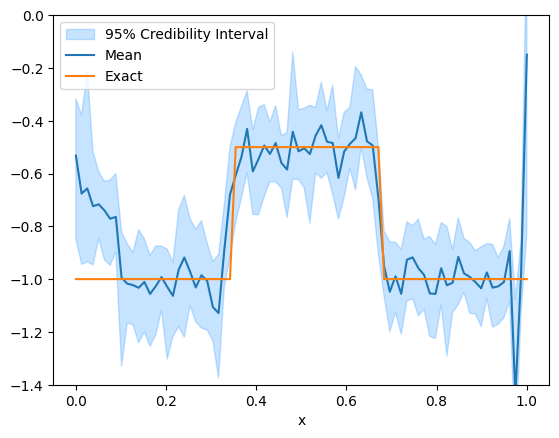

In [ ]:
# Switch samples geometry to Continuous1D for better plotting of the credibility interval
samples_ula.geometry = Continuous1D(np.flip(mesh.coordinates()[:,0]))

samples_ula.plot_ci(95, exact=m_true)
plt.ylim(-1.4,0)

We notice that the credible interval roughly captures the true solution, but both the credibal interval and the mean are highly oscillatory and do not capture the piecewise constant nature of the true solution. In the next section, we impose a TV-type implicit prior through the MYULA framework to capture the piecewise constant nature of the true solution.

## 2.4. BIP setup with TV-type implicit prior


#### Principles behind MYULA sampling method


The Moreau-Yosida Unadjusted Langevin (MYULA) Algorithm was introduced in {cite}`durmus2018efficient` as an extension of the ULA algorithm to allow sampling from posterior distributions with non-differentiable priors, such as the TV prior. The main idea behind MYULA is to use Moreau-Yosida regularization to create a smoothed version of the original non-differentiable prior, which allows us to compute the gradient needed for the Langevin updates.

To take an ULA step, as described above, we need the gradient of the log-posterior which involves the gradient of the log-prior $-R(m) :=\log p(m)$. In the case where $g(m)$ is not differentiable we can consider as surrogate posterior density $p_{\alpha} (m|y^\text{obs}) \propto p(y^\text{obs}|m) p_{\alpha} (m)$ where $p_{\alpha}(m)$ is a smoothed version of the original prior $e^{-R(m)}$. 

In the MYULA algorithm, the gradient of the log of this surrogate posterior density is used to perform the Langevin updates,
and a Moreau-Yosida smoothing is applied to the potential $R(m)$ as follows

$$
\begin{align*}
       R_\alpha(m) = \operatorname{inf}_z \left\{\frac{1}{2}\| m- z \|_2^2 + \alpha R(z)\right\}.

\end{align*}
$$

$ R_\alpha(m)$ is the smoothed version of $R(m)$ and $p_\alpha(m)$ is the corresponding smoothed prior. The smoothing strength $\alpha$ controls how closely the surrogate posterior approximates the original posterior, and as it goes to zero, the surrogate posterior converges to the original posterior. $R_\alpha(m)$ is continuously differentiable and its gradient can be computed using the proximal operator of $R$ as follows {ref}`Bauschke2017`

$$
\begin{align*}
         \nabla R_\alpha(m) = \frac{1}{\alpha} (m - \operatorname{prox}_{\alpha R}(m)).
\end{align*}    
$$

The proximal operator of $R$, $\operatorname{prox}_{\alpha R}(m)$, is defined as follows

$$
\begin{align*}
\operatorname{prox}_{\alpha R}(m) = \operatorname{argmin}_z \left\{\frac{1}{2}\| m- z \|_2^2 + \alpha R(z)\right\}.
\end{align*}
$$

My ULA step for sampling from the surrogate posterior is then given by

$$
\begin{align*}
m_{k+1} &= m_k + \delta \nabla \log L(m_k|y^\text{obs}) + \delta \nabla \log p_{\alpha}(m_k) + \sqrt{2\delta} \xi_k\\
&= m_k + \delta \nabla \log L(m_k|y^\text{obs}) - \delta \nabla R_\alpha(m_k) + \sqrt{2\delta} \xi_k\\
&= m_k + \delta \nabla \log L(m_k|y^\text{obs}) - \frac{\delta}{\alpha} (m_k - \operatorname{prox}_{\alpha R}(m_k)) + \sqrt{2\delta} \xi_k.
\end{align*}
$$




#### TV-denoiser-based prior

We want to impose a TV-type implicit prior on the log conductivity field $m$ to capture the piecewise constant nature of the true solution. In this case, the potential is given by the non-differentiable TV function of $m$ as follows

$$
\begin{align*}
R_{TV}^\lambda(m) = \lambda ||\nabla m||_{2,1} 
\end{align*}
$$

where $\lambda$ is the regularization parameter that controls the strength of the TV regularization. To apply MYULA, we only need the proximal operator of this TV function, which is also known as a TV denoising operator. This operator takes a signal as input
and returns a less noisy signal and is available in, e.g., [scikit-image](https://scikit-image.org/docs/stable/api/skimage.restoration.html#skimage.restoration.denoise_tv_chambolle). In CUQIpy, we use the term "restoration operator" as a general term to refer to denoising operators, as well as other types of operators that can be used to define implicit priors through the MYULA and PnPULA {ref}`laumont2022bayesian` frameworks. 

To create a TV-denoiser-based prior in CUQIpy, we use the [RestorationPrior](https://cuqi-dtu.github.io/CUQIpy/api/_autosummary/cuqi.implicitprior/cuqi.implicitprior.RestorationPrior.html) and the [MoreauYoshidaPrior](https://cuqi-dtu.github.io/CUQIpy/api/_autosummary/cuqi.implicitprior/cuqi.implicitprior.MoreauYoshidaPrior.html) classes. The `RestorationPrior` requires as input a restoration operator, which in our case is the TV denoising operator. This operator is provided in the form of a function that takes a signal and the a parameter controlling the strength of restoration `restoration_strength` as input and returns the denoised (restored) signal.






In [35]:
def restore_TV(x, restoration_strength=None):

    denoised_image = denoise_tv_chambolle(x,
        weight=restoration_strength,
        max_num_iter=100)
    return  denoised_image, None

We use the `restore_TV` function to create the `RestorationPrior` object as follows

In [36]:
restorator = RestorationPrior(
        restore_TV,
        geometry=F.domain_geometry
    )

Then we define our smoothed TV prior `m_tv` as follows

In [37]:
alpha = 0.5*noise**2 
reg_strength = 200
m_tv = MoreauYoshidaPrior(restorator, smoothing_strength=alpha, reg_strength=reg_strength)

The `MoreauYoshidaPrior` object, `m_tv`, provides the gradient of the Moreau-Yoshida smoothed version of the original TV prior with smoothing strength `alpha` ($\alpha$). The parameter `reg_strength` controls the strength of the TV regularization term relative to the likelihood term in the posterior distribution. The larger the `reg_strength` parameter, the stronger the TV regularization term, driving the inferred solution to be more piecewise constant. 

Now we can create the data distribution and the posterior distribution as follows

In [ ]:
y_tv = Gaussian(F(m_tv), noise**2, geometry=F.range_geometry)
posterior_tv = JointDistribution(y_tv, m_tv)(y_tv=y_obs)


Then we samples using the ULA algorithm with the smoothed TV prior, which is in essence the MYULA algorithm, as follows

In [39]:
scale_myula =2e-6
initial_point_myula = np.ones(n)*-0.75
sampler_myula = ULA(posterior_tv, scale=scale_myula, initial_point=initial_point_myula)

sampler_myula.sample(Ns, Nt=Nt)
samples_myula = sampler_myula.get_samples()

Sample:   0%|          | 0/100000 [00:00<?, ?it/s]

Sample: 100%|██████████| 100000/100000 [42:35<00:00, 39.14it/s, acc rate: 100.00%] 


And we plot the credible intervals for the MYULA samples

(-1.4, 0.0)

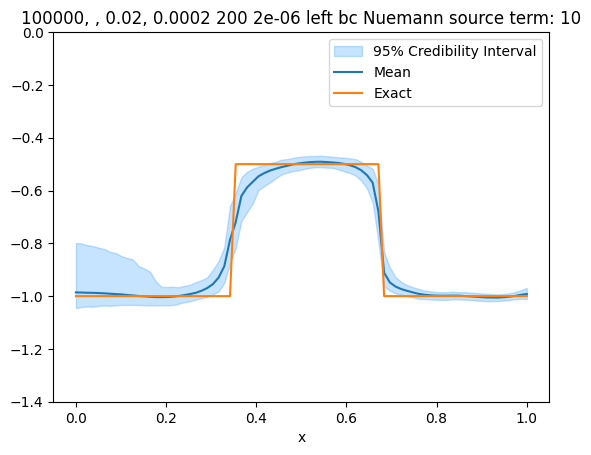

In [ ]:
# Switch samples geometry to Continuous1D for better plotting of the credibility interval
samples_myula.geometry = Continuous1D(np.flip(mesh.coordinates()[:,0]))

samples_myula.plot_ci(95, exact=m_true)
plt.title(str(Ns)+", "+", "+str(noise)+", "+str(alpha)+" "+str(reg_strength)+" "+str(scale_myula)+" left bc Nuemann"+ " source term: "+str(source_signal))
plt.ylim(-1.4,0)

Note that the MYULA samples are much less oscillatory than the ULA samples with GMRF prior, and they capture the piecewise constant nature of the true solution much better.

:::{admonition} **Reflection**

Reflect on the learning objectives of this notebook. Do you think you have achieved them? If not, what do you think is missing?

:::